# Does Economic Growth Translate into Human Development?
### An Empirical Statistical Analysis of Economic Prosperity, Inequality, Poverty, and Human Development Across Countries

**Notebook 1 of 2: Data Acquisition, Cleaning, and Exploration**

This notebook documents the full data pipeline for this project — from
official source to analysis-ready panel — and explores the resulting data
before any modelling is attempted in Notebook 2
(`02_statistical_analysis.ipynb`).

## 1. Research Motivation

**Why economic growth matters, and why it might not be enough.** Gross
Domestic Product (GDP) and Gross National Income (GNI) per capita remain the
default shorthand for national "progress" in policy and media discourse.
But GDP measures the *volume* of market production, not how the proceeds of
that production are distributed, nor whether they translate into longer,
healthier, better-educated lives. A country can grow richer in aggregate
while a large share of its population sees little improvement in health or
education outcomes — a possibility GDP alone cannot detect.

**Why human development matters.** The UNDP's Human Development Index (HDI)
was created explicitly as a response to this limitation: a composite measure
combining a *health* dimension (life expectancy at birth), an *education*
dimension (expected and mean years of schooling), and a *living standards*
dimension (GNI per capita), on the premise that development should be judged
by what people can *do and be*, not only by what an economy produces.

**Why inequality and poverty matter.** Average income growth is compatible
with very different distributional outcomes. Two countries with identical
GDP per capita can have very different median living standards depending on
how income is distributed (captured here by the Gini coefficient) and how
many people remain below a basic subsistence threshold (captured by poverty
headcount ratios). If human development tracks the *median* or *poorer*
citizen's circumstances more than the *average* one, inequality and poverty
should show an independent statistical association with HDI, beyond income
alone.

**Why statistical analysis is useful.** Cross-country development data are
observational, noisy, and often incomplete. Statistical tools — regression,
confidence intervals, robustness and sensitivity analysis, residual analysis
— let us describe the strength, shape, and stability of the income–inequality–
development relationship honestly, without overstating what the data can
support (in particular, without claiming causality that an observational,
cross-sectional design cannot establish).

### Research Questions

- **RQ1 (Income):** Is higher income per capita associated with higher HDI?
- **RQ2 (Inequality):** Among countries at similar income levels, is greater
  inequality associated with weaker HDI outcomes?
- **RQ3 (Poverty):** How is poverty associated with HDI after accounting for
  income?
- **RQ4 (Heterogeneity):** Do countries with similar income exhibit
  substantially different HDI?
- **RQ5 (Relative performance):** Which countries have HDI substantially
  higher or lower than their income level would predict?
- **RQ6 (Development dimensions):** Are income's associations with different
  development dimensions (health, education) similar or different?

### Hypotheses (pre-specified before viewing final regression results)

- **H1:** Countries with higher income per capita tend to have higher HDI
  (β₁ > 0).
- **H2:** Greater inequality is negatively associated with HDI conditional
  on income (β₂ < 0) — *not assumed to hold; to be tested.*
- **H3:** Countries with similar income can exhibit substantially different
  HDI (heterogeneity).
- **H4:** Some countries achieve HDI substantially higher than their income
  alone would predict.

### A methodological constraint stated up front

HDI is *constructed from* life expectancy, schooling, and income. Regressing
HDI on its own components would therefore be close to tautological. This
project uses **income and distributional variables** (GDP per capita, Gini,
poverty) as predictors of HDI, and treats life expectancy / schooling as
**separate outcomes** analysed on their own (RQ6), never as predictors of
HDI. See `data/processed/data_dictionary.md` for the full variable-role
documentation.

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['figure.facecolor'] = 'white'

FIGDIR = '../figures'
import os
os.makedirs(FIGDIR, exist_ok=True)

RNG_SEED = 42
np.random.seed(RNG_SEED)

## 2. Data Sources

All data come from official statistics or from actively-maintained,
citation-preserving mirrors of official statistics, pinned to a specific
version for reproducibility rather than called live at run time (see the
rationale at the end of `data/raw/SOURCES.md`).
**No Kaggle datasets or unattributed scrapes are used.**

| Variable | Official source | Indicator / table |
|---|---|---|
| HDI | UNDP Human Development Report Office | HDR 2023/24 Statistical Annex, Table 2 |
| GDP, Population | World Bank | `NY.GDP.MKTP.CD`, `SP.POP.TOTL` |
| Gini index | World Bank | `SI.POV.GINI` |
| Poverty headcount ratio | World Bank Poverty & Inequality Platform | international poverty line |
| Country / UN region | ISO 3166-1 / UN Statistics Division M49 | — |
| Life expectancy, schooling (secondary, RQ6) | World Bank / UNDP (older vintage archive) | — |

Full provenance — exact URLs, retrieval dates, indicator codes, and known
limitations of each source — is documented in **`data/raw/SOURCES.md`**.
The complete variable-level data dictionary (definition, unit, coverage,
analytical role) is in **`data/processed/data_dictionary.md`**.

## 3. Data Acquisition and Processing

Data acquisition and cleaning are implemented as two standalone,
reproducible scripts rather than inline notebook code, per the project's
"keep notebooks to two, put reusable logic in scripts" constraint:

- **`src/fetch_raw_data.py`** downloads every raw file from its canonical
  URL into `data/raw/` (never overwriting/mutating the raw files afterward).
- **`src/data_processing.py`** reads only from `data/raw/`, performs all
  cleaning and harmonization, and writes the analysis-ready files to
  `data/processed/`.

Running the cell below regenerates the entire raw → processed pipeline from
scratch and prints a coverage summary.

In [2]:
import fetch_raw_data
import data_processing

fetch_raw_data.main()
print()
data_processing.main()

Fetching HDR23-24_HDI_Trends.xlsx ...
  -> data/raw/HDR23-24_HDI_Trends.xlsx (58,423 bytes)
Fetching gdp_worldbank.csv ...
  -> data/raw/gdp_worldbank.csv (562,767 bytes)
Fetching gini_worldbank.csv ...
  -> data/raw/gini_worldbank.csv (54,891 bytes)
Fetching population_worldbank.csv ...
  -> data/raw/population_worldbank.csv (552,112 bytes)
Fetching country_codes.csv ...
  -> data/raw/country_codes.csv (134,003 bytes)
Fetching poverty_worldbank_pip.csv ...
  -> data/raw/poverty_worldbank_pip.csv (7,771,606 bytes)
Fetching owid_dimensions/life_expectancy.csv ...
  -> data/raw/owid_dimensions/life_expectancy.csv (355,132 bytes)
Fetching owid_dimensions/expected_years_schooling.csv ...
  -> data/raw/owid_dimensions/expected_years_schooling.csv (97,313 bytes)
Fetching owid_dimensions/mean_years_schooling.csv ...
  -> data/raw/owid_dimensions/mean_years_schooling.csv (143,545 bytes)

[life_expectancy] 36 entities could not be matched to ISO3 (likely aggregates/regions, excluded): ['Arab Wo

In [3]:
panel = pd.read_csv('../data/processed/analytical_panel.csv')
cross = pd.read_csv('../data/processed/cross_section_2022.csv')
dims = pd.read_csv('../data/processed/dimensions_latest_available.csv')

print(f'Panel (country-year, 1990-2022): {panel.shape}')
print(f'Cross-section (2022):            {cross.shape}')
print(f'Dimensions snapshot (RQ6):        {dims.shape}')
cross.head()

Panel (country-year, 1990-2022): (1471, 17)
Cross-section (2022):            (193, 17)
Dimensions snapshot (RQ6):        (191, 8)


,country,country_code,year,hdi,hdi_rank_2022,gdp_current_usd,population,gdp_per_capita_usd,gini_index,gini_index_source_year,poverty_headcount_ratio,poverty_headcount_ratio_source_year,life_expectancy,expected_years_schooling,mean_years_schooling,un_region,un_subregion
0,Afghanistan,AFG,2022,0.462,182,1.450216e+10,40578842,357.382258,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Asia,Southern Asia
1,Angola,AGO,2022,0.591,150,1.043997e+11,35635029,2929.694455,51.3,2018.0,49.902954,2018.0,NaN,NaN,NaN,Africa,Sub-Saharan Africa
2,Albania,ALB,2022,0.789,74,1.891638e+10,2451636,7715.818686,29.4,2020.0,0.000000,2019.0,NaN,NaN,NaN,Europe,Southern Europe
3,Andorra,AND,2022,0.884,35,3.380602e+09,79705,42413.926891,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Europe,Southern Europe
4,United Arab Emirates,ARE,2022,0.937,17,5.070640e+11,10074977,50329.044749,26.4,2018.0,NaN,NaN,NaN,NaN,NaN,Asia,Western Asia


## 4. Data Cleaning — What Was Done and Why

The main cleaning challenge in this project is **country-name harmonization**:
the UNDP HDR annex, World Bank series, and the World Bank Poverty and
Inequality Platform each use slightly different country-name conventions
(e.g. *"Türkiye"* vs. *"Turkey"*, *"Côte d'Ivoire"* vs. *"Cote d'Ivoire"*,
*"Korea (Republic of)"* vs. *"South Korea"*). `src/data_processing.py`
builds a name → ISO3 crosswalk from the UN's own `country-codes` reference
file and layers a small, fully-listed set of manual overrides on top for
names that reference data does not already contain.

Other cleaning decisions, all made explicitly in code (not silently):

- HDR annex aggregate rows (e.g. *"Sub-Saharan Africa"*, *"World"*,
  *"Very high human development"*) are excluded — these are not countries.
- The HDR annex encodes genuinely unavailable country-year HDI values with
  `".."`; these are treated as missing (`NaN`), never coerced to zero or
  interpolated.
- World Bank income-group aggregate rows in the life-expectancy archive
  (*"High income"*, *"OECD members"*, etc.) are excluded from the
  country-level panel.
- Gini and poverty are household-survey based and reported irregularly
  (not annually). Rather than only keeping exact-year matches — which would
  discard most countries — each is matched to the **nearest available survey
  year within a ±5-year window** of the target year, and the *actual* survey
  year used is retained as a separate column (`..._source_year`) so every
  linked value's vintage is auditable, never silently smoothed over.
- No country was dropped simply for having missing data on some variables;
  missingness is documented in Section 5 below and left as missingness.

The full logged output of every unmatched name (all confirmed to be
aggregates, not real excluded countries) is visible in the acquisition cell
above.

## 5. Missing-Data Analysis

This section is mandatory per the project's methodological constraints:
missingness must be reported, not silently imputed or hidden.

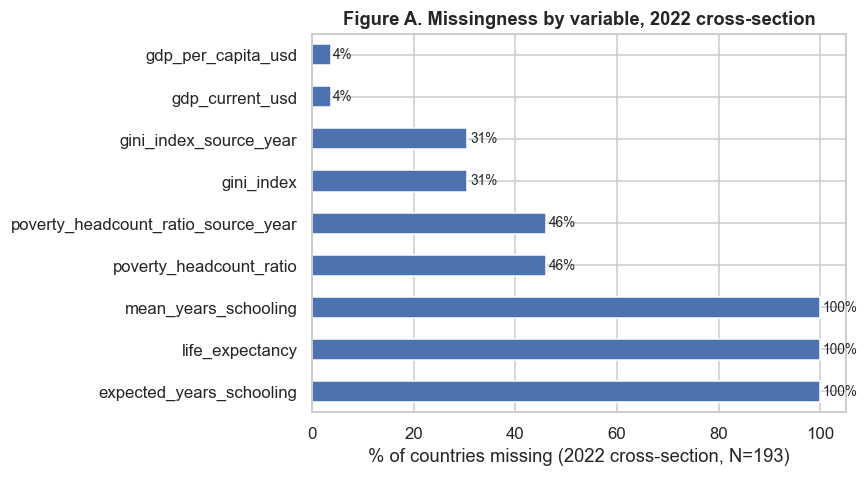

Countries with a 2022 HDI value: 193
Note: life_expectancy / expected_years_schooling / mean_years_schooling are
100% missing in the 2022 cross-section BY CONSTRUCTION -- their source archives
stop in 2013 / 2017 respectively (see SOURCES.md). They are analysed separately
in Notebook 2 using the most-recent-available year per country, not the 2022 slice.


In [4]:
miss = cross.drop(columns=['country', 'country_code', 'year']).isna().mean().sort_values(ascending=False) * 100
miss = miss[miss > 0]

fig, ax = plt.subplots(figsize=(8, 4.5))
miss.plot(kind='barh', ax=ax, color='#4C72B0')
ax.set_xlabel('% of countries missing (2022 cross-section, N=193)')
ax.set_title('Figure A. Missingness by variable, 2022 cross-section')
for i, v in enumerate(miss.values):
    ax.text(v + 0.5, i, f'{v:.0f}%', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig_A_missingness_by_variable.png', dpi=150)
plt.show()

print('Countries with a 2022 HDI value:', cross['hdi'].notna().sum())
print('Note: life_expectancy / expected_years_schooling / mean_years_schooling are')
print('100% missing in the 2022 cross-section BY CONSTRUCTION -- their source archives')
print('stop in 2013 / 2017 respectively (see SOURCES.md). They are analysed separately')
print('in Notebook 2 using the most-recent-available year per country, not the 2022 slice.')

In [5]:
gap_summary = pd.DataFrame({
    'gini_gap_years': (2022 - cross['gini_index_source_year']).dropna(),
})
gap_summary2 = (2022 - cross['poverty_headcount_ratio_source_year']).dropna()

print('Gini: matched-survey gap from 2022 (years) —')
print(gap_summary['gini_gap_years'].describe())
print()
print('Poverty: matched-survey gap from 2022 (years) —')
print(gap_summary2.describe())

Gini: matched-survey gap from 2022 (years) —
count    134.000000
mean       1.231343
std        1.635665
min       -1.000000
25%        0.000000
50%        1.000000
75%        2.000000
max        5.000000
Name: gini_gap_years, dtype: float64

Poverty: matched-survey gap from 2022 (years) —
count    104.000000
mean       3.326923
std        0.928955
min        1.000000
25%        3.000000
50%        3.000000
75%        4.000000
max        5.000000
Name: poverty_headcount_ratio_source_year, dtype: float64


In [6]:
dims_cov = dims.drop(columns=['country', 'country_code']).notna().sum()
print('Dimensions snapshot coverage (most recent available year per country, N=%d countries):' % len(dims))
for col in ['life_expectancy', 'expected_years_schooling', 'mean_years_schooling']:
    n = dims[col].notna().sum()
    yr_col = col + '_year'
    yrs = dims[yr_col].dropna()
    print(f'  {col:28s}: {n:3d}/{len(dims)} countries, source years {int(yrs.min())}-{int(yrs.max())} (median {int(yrs.median())})')

Dimensions snapshot coverage (most recent available year per country, N=191 countries):
  life_expectancy             : 186/191 countries, source years 2000-2010 (median 2010)
  expected_years_schooling    : 189/191 countries, source years 2015-2015 (median 2015)
  mean_years_schooling        : 189/191 countries, source years 1990-2015 (median 2015)


**Summary:** HDI itself is essentially complete (193/193 with a 2022
value). GDP per capita is well covered (186/193, 96%). Gini and poverty are
the two variables with genuine, expected missingness — inequality and
poverty statistics require household surveys that many countries do not run
annually, and some (mostly small, high-income, or fragile states) rarely run
at all. This missingness is **not random with respect to country
characteristics** (poorer and more fragile states are more likely to lack
recent survey data) — a limitation carried through to every model that uses
Gini or poverty in Notebook 2, and discussed explicitly in the
limitations section.

### Quantifying the Missingness Bias

Section 5 states that Gini/poverty missingness is "not random with respect
to country characteristics" but did not previously quantify this. Tested
here with a two-sided Mann-Whitney U test (chosen over a t-test because
income is heavily right-skewed) comparing income and HDI between countries
with vs. without each variable.


In [7]:
from scipy import stats

for var, label in [('gini_index', 'Gini'), ('poverty_headcount_ratio', 'Poverty')]:
    covered = cross[var].notna()
    print(f'--- {label} coverage bias (covered N={covered.sum()}, uncovered N={(~covered).sum()}) ---')
    for col in ['gdp_per_capita_usd', 'hdi']:
        a = cross.loc[covered, col].dropna()
        b = cross.loc[~covered, col].dropna()
        u, p = stats.mannwhitneyu(a, b, alternative='two-sided')
        print(f'  {col:20s}: covered median={a.median():>10.3f}  uncovered median={b.median():>10.3f}  Mann-Whitney p={p:.4f}')
    print()

unc_poverty = cross[cross['poverty_headcount_ratio'].isna()].sort_values('gdp_per_capita_usd')
print('Poverty-uncovered countries by income (lowest 5 / highest 3, illustrating the pattern):')
print(unc_poverty[['country', 'gdp_per_capita_usd', 'hdi']].head(5).to_string(index=False))
print('...')
print(unc_poverty[['country', 'gdp_per_capita_usd', 'hdi']].tail(3).to_string(index=False))


--- Gini coverage bias (covered N=134, uncovered N=59) ---
  gdp_per_capita_usd  : covered median=  6729.847  uncovered median=  6496.973  Mann-Whitney p=0.7652
  hdi                 : covered median=     0.762  uncovered median=     0.717  Mann-Whitney p=0.1021

--- Poverty coverage bias (covered N=104, uncovered N=89) ---
  gdp_per_capita_usd  : covered median=  8331.740  uncovered median=  5141.391  Mann-Whitney p=0.0631
  hdi                 : covered median=     0.784  uncovered median=     0.702  Mann-Whitney p=0.0029

Poverty-uncovered countries by income (lowest 5 / highest 3, illustrating the pattern):
                 country  gdp_per_capita_usd   hdi
                 Burundi          250.634225 0.420
             Afghanistan          357.382258 0.462
Central African Republic          467.359825 0.387
              Madagascar          502.755833 0.487
              Mozambique          563.654362 0.461
...
                           country  gdp_per_capita_usd   hdi
          

**Interpretation:** the bias is asymmetric across the two variables.
**Gini** coverage is *not* significantly different by income or HDI
(p = 0.77 and 0.10) — missingness here looks closer to random with respect
to these two variables specifically. **Poverty** coverage is significantly
biased (p = 0.003 for HDI, p = 0.06 for income): covered countries have
*higher* median income and HDI than uncovered ones. Looking at which
countries are uncovered shows why — it is **bimodal, not one-directional**:
the poorest, most fragile states (Burundi, Afghanistan, Central African
Republic — no survey infrastructure) are missing, but so are a handful of
very high-income states (Singapore, Qatar, Liechtenstein — poverty at the
$2.15/day line is not tracked the same way when it is close to zero), plus
several data-poor states affected by conflict or sanctions with *no* income
figure either (Cuba, Syria, Venezuela, Yemen, South Sudan). **Practical
consequence:** the poverty-model sample (Model 3, Notebook 2) is tilted
toward the middle of the global income/HDI distribution and under-represents
both tails — a sharper, more specific caveat than "skews toward poorer
countries," and the one carried into Notebook 2's limitations section.


## 6. Descriptive Statistics

In [8]:
desc_vars = ['hdi', 'gdp_per_capita_usd', 'gini_index', 'poverty_headcount_ratio']
desc = cross[desc_vars].describe(percentiles=[.1, .25, .5, .75, .9]).T
desc['skew'] = cross[desc_vars].skew()
desc

,count,mean,std,min,10%,25%,50%,75%,90%,max,skew
hdi,193.0,0.723741,0.155177,0.380000,0.496800,0.602000,0.740000,0.847000,0.927000,0.967000,-0.350334
gdp_per_capita_usd,186.0,17308.976115,25919.699164,250.634225,988.444430,2328.989706,6702.221309,20808.505439,49523.641798,186479.996838,2.994567
gini_index,134.0,35.416418,6.645369,24.100000,26.960000,30.700000,34.350000,39.100000,44.640000,54.800000,0.635688
poverty_headcount_ratio,104.0,8.063598,15.206289,0.000000,0.016339,0.177329,0.961402,6.790002,31.402052,73.523892,2.402107


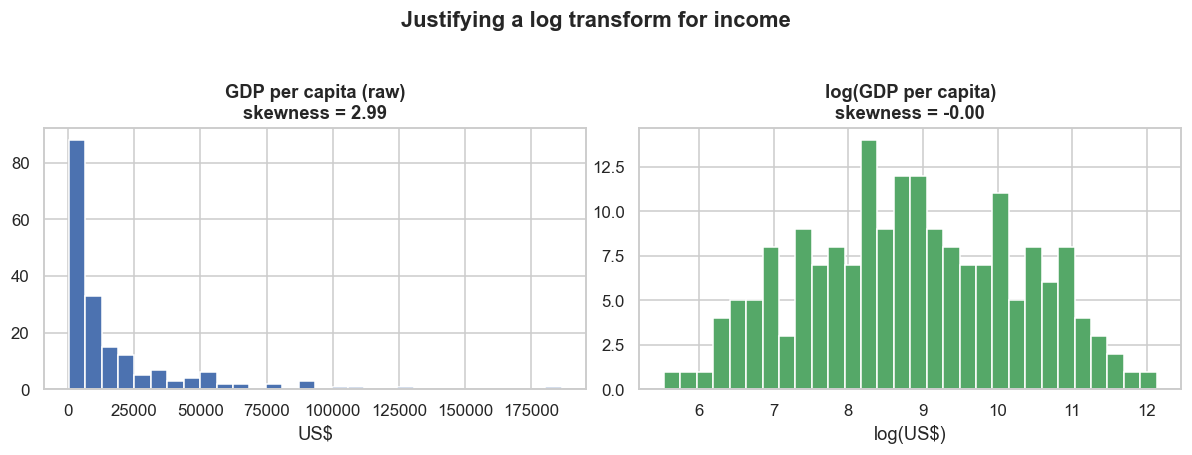

Raw GDP per capita is heavily right-skewed (a small number of very high-income
countries stretch the distribution); log(GDP per capita) is close to symmetric.
All models in Notebook 2 use log(GDP per capita), consistent with the diminishing
marginal association between income and wellbeing widely found in this literature.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(cross['gdp_per_capita_usd'].dropna(), bins=30, color='#4C72B0', edgecolor='white')
axes[0].set_title(f"GDP per capita (raw)\nskewness = {cross['gdp_per_capita_usd'].skew():.2f}")
axes[0].set_xlabel('US$')

log_gdp = np.log(cross['gdp_per_capita_usd'].dropna())
axes[1].hist(log_gdp, bins=30, color='#55A868', edgecolor='white')
axes[1].set_title(f"log(GDP per capita)\nskewness = {log_gdp.skew():.2f}")
axes[1].set_xlabel('log(US$)')
plt.suptitle('Justifying a log transform for income', y=1.03, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig_B_income_skew_log_justification.png', dpi=150, bbox_inches='tight')
plt.show()

print('Raw GDP per capita is heavily right-skewed (a small number of very high-income')
print('countries stretch the distribution); log(GDP per capita) is close to symmetric.')
print('All models in Notebook 2 use log(GDP per capita), consistent with the diminishing')
print('marginal association between income and wellbeing widely found in this literature.')

## 7. Exploratory Visualization

Nine focused figures, each addressing a specific question raised in Section
1 — not generated simply to pad the notebook.

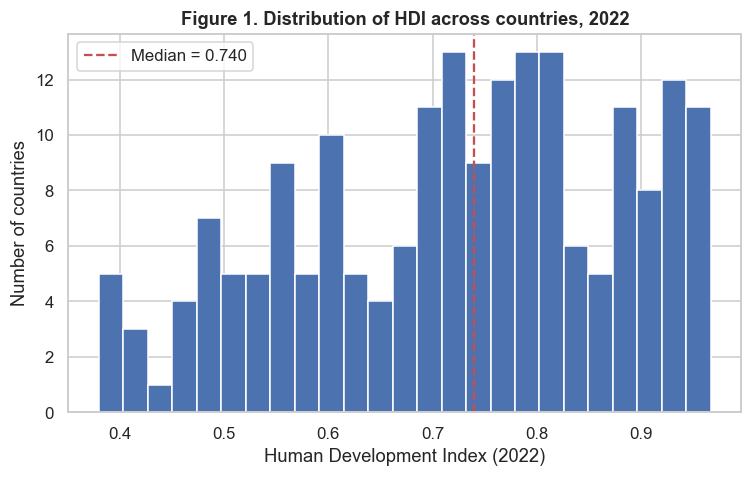

In [10]:
# Figure 1: Distribution of HDI
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(cross['hdi'].dropna(), bins=25, color='#4C72B0', edgecolor='white')
ax.axvline(cross['hdi'].median(), color='#C44E52', linestyle='--', label=f"Median = {cross['hdi'].median():.3f}")
ax.set_xlabel('Human Development Index (2022)')
ax.set_ylabel('Number of countries')
ax.set_title('Figure 1. Distribution of HDI across countries, 2022')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig_1_hdi_distribution.png', dpi=150)
plt.show()

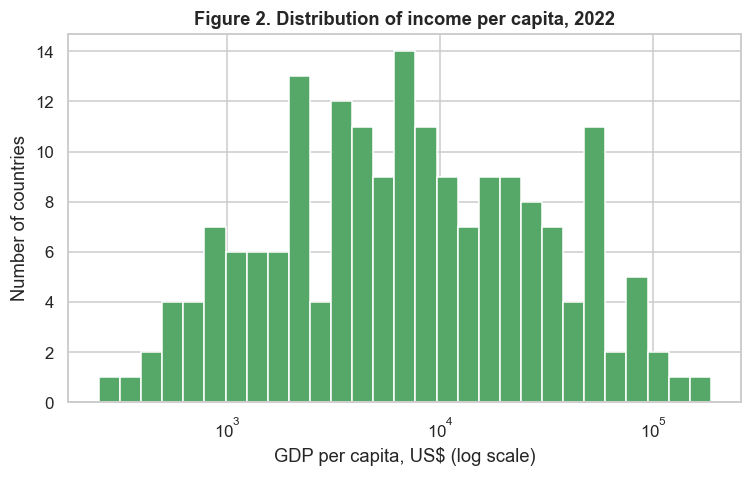

In [11]:
# Figure 2: Distribution of income per capita (log scale)
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(cross['gdp_per_capita_usd'].dropna(), bins=np.logspace(
    np.log10(cross['gdp_per_capita_usd'].min()), np.log10(cross['gdp_per_capita_usd'].max()), 30),
    color='#55A868', edgecolor='white')
ax.set_xscale('log')
ax.set_xlabel('GDP per capita, US$ (log scale)')
ax.set_ylabel('Number of countries')
ax.set_title('Figure 2. Distribution of income per capita, 2022')
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig_2_income_distribution.png', dpi=150)
plt.show()

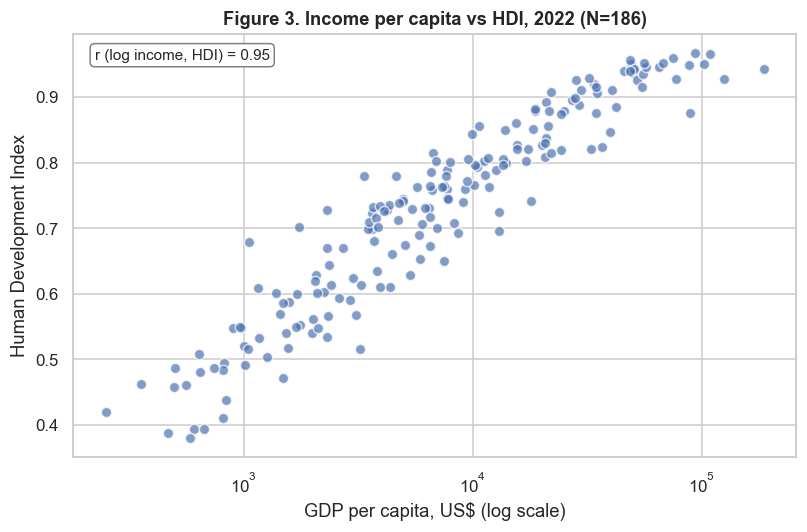

In [12]:
# Figure 3: Income per capita vs HDI
d = cross.dropna(subset=['gdp_per_capita_usd', 'hdi'])
fig, ax = plt.subplots(figsize=(7.5, 5))
sc = ax.scatter(d['gdp_per_capita_usd'], d['hdi'], c='#4C72B0', alpha=0.7, edgecolor='white', s=45)
ax.set_xscale('log')
ax.set_xlabel('GDP per capita, US$ (log scale)')
ax.set_ylabel('Human Development Index')
ax.set_title('Figure 3. Income per capita vs HDI, 2022 (N=%d)' % len(d))
r, p = stats.pearsonr(np.log(d['gdp_per_capita_usd']), d['hdi'])
ax.text(0.03, 0.94, f'r (log income, HDI) = {r:.2f}', transform=ax.transAxes,
        fontsize=10, bbox=dict(boxstyle='round', fc='white', ec='gray'))
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig_3_income_vs_hdi.png', dpi=150)
plt.show()

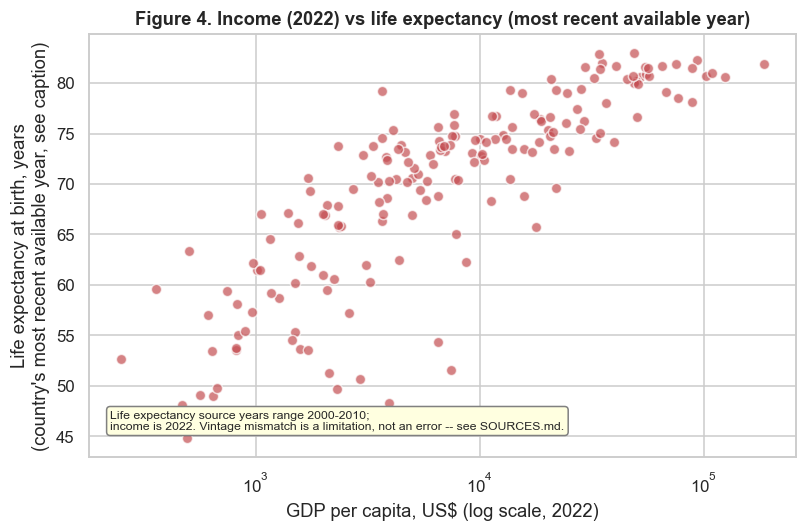

In [13]:
# Figure 4: Income per capita vs life expectancy (RQ6, secondary-dimension snapshot)
d4 = dims.dropna(subset=['life_expectancy']).merge(
    cross[['country_code', 'gdp_per_capita_usd']], on='country_code', how='left').dropna(subset=['gdp_per_capita_usd'])
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.scatter(d4['gdp_per_capita_usd'], d4['life_expectancy'], c='#C44E52', alpha=0.7, edgecolor='white', s=45)
ax.set_xscale('log')
ax.set_xlabel('GDP per capita, US$ (log scale, 2022)')
ax.set_ylabel("Life expectancy at birth, years\n(country's most recent available year, see caption)")
ax.set_title('Figure 4. Income (2022) vs life expectancy (most recent available year)')
ax.text(0.03, 0.06,
        f"Life expectancy source years range {int(d4['life_expectancy_year'].min())}-{int(d4['life_expectancy_year'].max())};\n"
        "income is 2022. Vintage mismatch is a limitation, not an error -- see SOURCES.md.",
        transform=ax.transAxes, fontsize=8, va='bottom',
        bbox=dict(boxstyle='round', fc='lightyellow', ec='gray'))
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig_4_income_vs_life_expectancy.png', dpi=150)
plt.show()

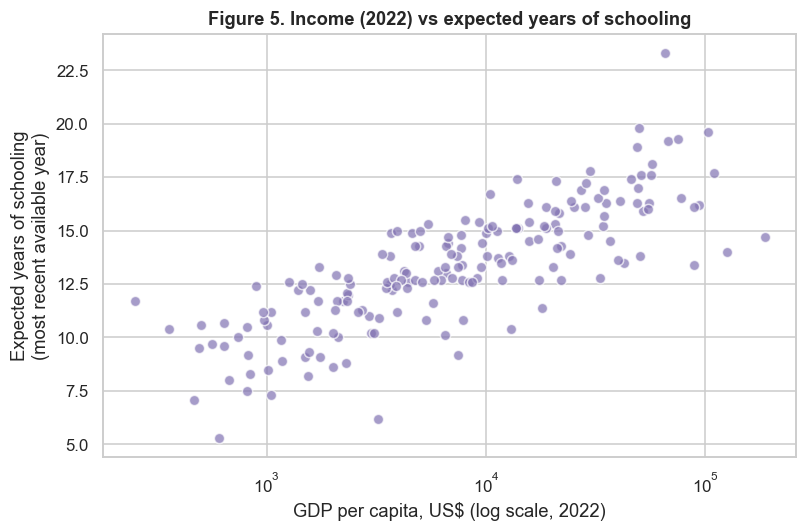

In [14]:
# Figure 5: Income per capita vs education (expected years of schooling)
d5 = dims.dropna(subset=['expected_years_schooling']).merge(
    cross[['country_code', 'gdp_per_capita_usd']], on='country_code', how='left').dropna(subset=['gdp_per_capita_usd'])
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.scatter(d5['gdp_per_capita_usd'], d5['expected_years_schooling'], c='#8172B2', alpha=0.7, edgecolor='white', s=45)
ax.set_xscale('log')
ax.set_xlabel('GDP per capita, US$ (log scale, 2022)')
ax.set_ylabel('Expected years of schooling\n(most recent available year)')
ax.set_title('Figure 5. Income (2022) vs expected years of schooling')
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig_5_income_vs_education.png', dpi=150)
plt.show()

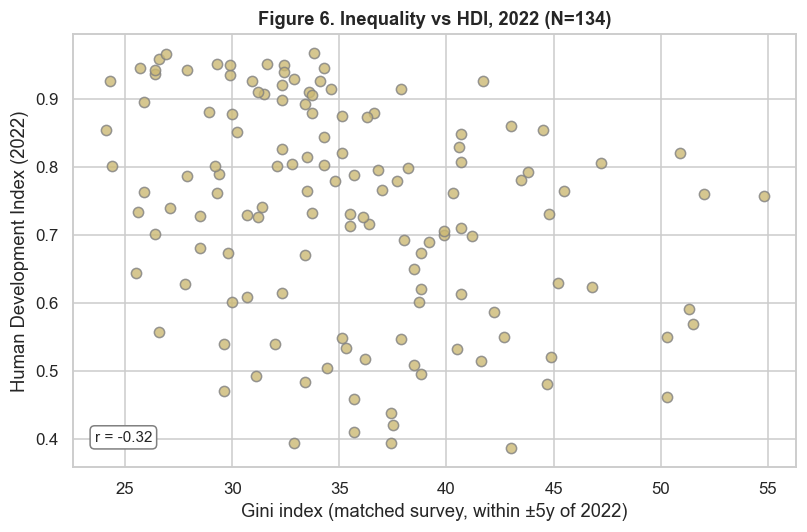

In [15]:
# Figure 6: Inequality (Gini) vs HDI
d6 = cross.dropna(subset=['gini_index', 'hdi'])
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.scatter(d6['gini_index'], d6['hdi'], c='#CCB974', alpha=0.8, edgecolor='gray', s=45)
ax.set_xlabel('Gini index (matched survey, within \u00b15y of 2022)')
ax.set_ylabel('Human Development Index (2022)')
ax.set_title('Figure 6. Inequality vs HDI, 2022 (N=%d)' % len(d6))
r, p = stats.pearsonr(d6['gini_index'], d6['hdi'])
ax.text(0.03, 0.06, f'r = {r:.2f}', transform=ax.transAxes, fontsize=10,
        bbox=dict(boxstyle='round', fc='white', ec='gray'))
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig_6_gini_vs_hdi.png', dpi=150)
plt.show()

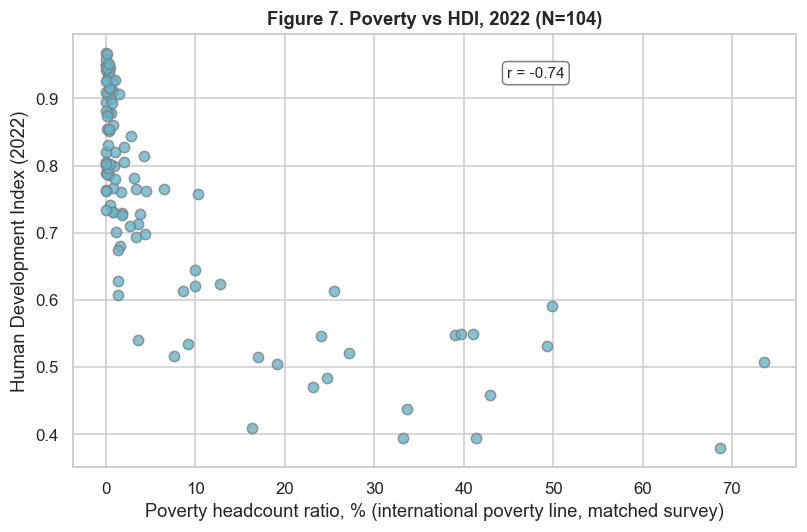

In [16]:
# Figure 7: Poverty vs HDI
d7 = cross.dropna(subset=['poverty_headcount_ratio', 'hdi'])
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.scatter(d7['poverty_headcount_ratio'], d7['hdi'], c='#64B5CD', alpha=0.8, edgecolor='gray', s=45)
ax.set_xlabel('Poverty headcount ratio, % (international poverty line, matched survey)')
ax.set_ylabel('Human Development Index (2022)')
ax.set_title('Figure 7. Poverty vs HDI, 2022 (N=%d)' % len(d7))
r, p = stats.pearsonr(d7['poverty_headcount_ratio'], d7['hdi'])
ax.text(0.6, 0.9, f'r = {r:.2f}', transform=ax.transAxes, fontsize=10,
        bbox=dict(boxstyle='round', fc='white', ec='gray'))
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig_7_poverty_vs_hdi.png', dpi=150)
plt.show()

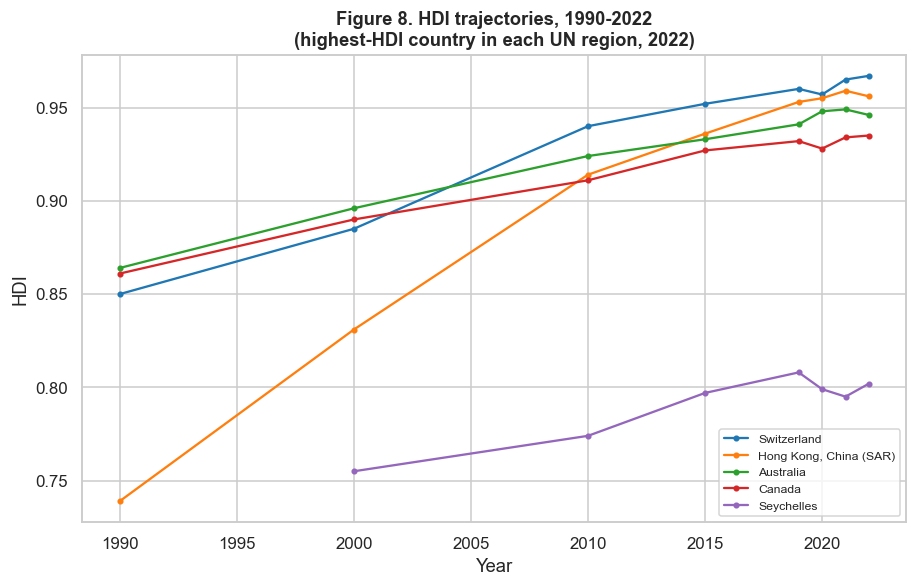

In [17]:
# Figure 8: HDI trajectories over time, selected countries per UN region
d8 = panel.dropna(subset=['hdi'])
reps = (d8[d8['year'] == 2022]
        .sort_values('hdi', ascending=False)
        .groupby('un_region')
        .head(1)['country_code'].tolist())
fig, ax = plt.subplots(figsize=(8.5, 5.5))
palette = sns.color_palette('tab10', n_colors=len(reps))
for cc, col in zip(reps, palette):
    sub = d8[d8['country_code'] == cc].sort_values('year')
    name = sub['country'].iloc[0]
    ax.plot(sub['year'], sub['hdi'], marker='o', markersize=3, label=name, color=col)
ax.set_xlabel('Year')
ax.set_ylabel('HDI')
ax.set_title('Figure 8. HDI trajectories, 1990-2022\n(highest-HDI country in each UN region, 2022)')
ax.legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig_8_hdi_trajectories.png', dpi=150)
plt.show()

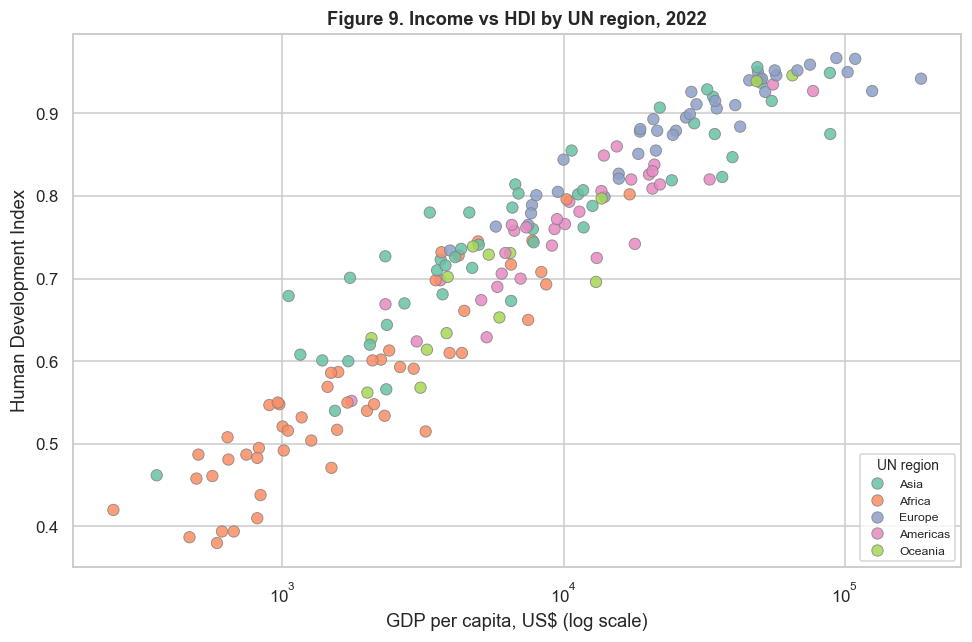

In [18]:
# Figure 9: Income vs HDI by UN region
d9 = cross.dropna(subset=['gdp_per_capita_usd', 'hdi', 'un_region'])
fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(data=d9, x='gdp_per_capita_usd', y='hdi', hue='un_region',
                 palette='Set2', s=55, alpha=0.85, edgecolor='gray', ax=ax)
ax.set_xscale('log')
ax.set_xlabel('GDP per capita, US$ (log scale)')
ax.set_ylabel('Human Development Index')
ax.set_title('Figure 9. Income vs HDI by UN region, 2022')
ax.legend(title='UN region', fontsize=8, title_fontsize=9, loc='lower right')
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig_9_income_hdi_by_region.png', dpi=150)
plt.show()

## Summary and Handoff to Notebook 2

- The processed analytical panel (`data/processed/analytical_panel.csv`,
  1990–2022) and 2022 cross-section (`cross_section_2022.csv`) are complete,
  documented, and reproducible from raw source via
  `src/fetch_raw_data.py` → `src/data_processing.py`.
- Income (log GDP per capita) shows a clear positive, concave-looking
  association with HDI (Figure 3) — consistent with H1, to be tested
  formally.
- Gini and poverty both show visible negative associations with HDI
  (Figures 6–7), but with real gaps in country coverage that will be
  reported alongside every model that uses them.
- Considerable heterogeneity is visible at similar income levels (Figure 9)
  and across regions — this motivates the residual / relative-performance
  analysis (RQ4, RQ5) in Notebook 2.
- Life expectancy and schooling (RQ6) are available only as an
  older-vintage, most-recent-available-year snapshot, not a 2022 cross-
  section — this is carried forward explicitly, not concealed.

All formal modelling, inference, robustness, and the residual
(relative-performance) analysis are conducted in
**`02_statistical_analysis.ipynb`**.